# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('cleaned_aviation_data.csv', parse_dates=['Event.Date'])
print(df.shape)
df.head()

(64201, 22)


,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Total.People,Fatal.Serious.Injuries,Serious.Fatal.Fraction,Destroyed,Make.Model
0,1983-01-01,"NEWPORT, OR",United States,Non-Fatal,Substantial,Cessna,182P,No,1.0,Reciprocating,...,0.0,1.0,3.0,VMC,Approach,4.0,0.0,0.0,0,Cessna 182P
1,1983-01-01,"WOODBINE, IA",United States,Non-Fatal,Substantial,Cessna,182RG,No,1.0,Reciprocating,...,0.0,0.0,2.0,VMC,Landing,2.0,0.0,0.0,0,Cessna 182RG
2,1983-01-01,"MARYVILLE, MO",United States,Non-Fatal,Substantial,Cessna,182P,No,1.0,Reciprocating,...,0.0,0.0,1.0,VMC,Takeoff,1.0,0.0,0.0,0,Cessna 182P
3,1983-01-01,"UPLAND, CA",United States,Non-Fatal,Substantial,Piper,PA-28R-200,No,1.0,Reciprocating,...,0.0,2.0,0.0,VMC,Approach,2.0,0.0,0.0,0,Piper PA-28R-200
4,1983-01-01,"SPRINGBROOK, WI",United States,Non-Fatal,Substantial,Cessna,140,No,1.0,Reciprocating,...,0.0,0.0,2.0,VMC,Landing,2.0,0.0,0.0,0,Cessna 140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

**Defining small vs. large aircraft.** We use `Total.People` (total occupants aboard) as a proxy for aircraft passenger capacity. Since a single accident record only reflects how many people happened to be aboard *that* flight (not the aircraft's true seating capacity), we instead look at the **maximum** `Total.People` ever recorded for a given `Make.Model` across all its accidents in our data, and use that as a capacity estimate for the plane type as a whole. Any plane type whose max observed occupancy is 20 or more is classified as `'Large'`; everything else is `'Small'`. Every record for a given plane type then gets the same size label, which keeps things consistent when we aggregate by Make below.

In [3]:
model_capacity = df.groupby('Make.Model')['Total.People'].max()
large_models = model_capacity[model_capacity >= 20].index

df['Size.Class'] = np.where(df['Make.Model'].isin(large_models), 'Large', 'Small')

print(df['Size.Class'].value_counts())
print()
print('Number of large plane types:', len(large_models))
print('Number of small plane types:', model_capacity[model_capacity < 20].shape[0])

Size.Class
Small    60566
Large     3635
Name: count, dtype: int64

Number of large plane types: 492
Number of small plane types: 5169


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

We require at least **30 accident records** for a Make within a size class before including it in these comparisons — this keeps our mean injury-fraction estimates statistically meaningful rather than being driven by one or two accidents.

In [4]:
MIN_N_MAKE = 30

def top_makes_by_safety(size_class, n_top=15, min_n=MIN_N_MAKE):
    sub = df[df['Size.Class'] == size_class]
    grp = sub.groupby('Make').agg(
        mean_frac=('Serious.Fatal.Fraction', 'mean'),
        n=('Serious.Fatal.Fraction', 'size'),
        destroyed_rate=('Destroyed', 'mean')
    )
    grp = grp[grp['n'] >= min_n]
    return grp.sort_values('mean_frac').head(n_top)

top_small_makes = top_makes_by_safety('Small')
top_large_makes = top_makes_by_safety('Large')

print('Small aircraft makes with n >=', MIN_N_MAKE, ':', (df[df['Size.Class']=='Small'].groupby('Make').size() >= MIN_N_MAKE).sum())
print('Large aircraft makes with n >=', MIN_N_MAKE, ':', (df[df['Size.Class']=='Large'].groupby('Make').size() >= MIN_N_MAKE).sum())

top_small_makes

Small aircraft makes with n >= 30 : 79
Large aircraft makes with n >= 30 : 14


,mean_frac,n,destroyed_rate
Make,,,
Waco,0.102657,138,0.086957
Grumman-Schweizer,0.104497,126,0.253968
Helio,0.140620,105,0.123810
Let,0.153061,98,0.102041
Maule,0.153281,569,0.093146
Enstrom,0.159558,211,0.156398
Boeing,0.163422,452,0.123894
Great Lakes,0.163793,58,0.137931
Aviat Aircraft Inc,0.164474,76,0.039474


In [5]:
top_large_makes

,mean_frac,n,destroyed_rate
Make,,,
Mcdonnell Douglas,0.074404,254,0.110236
Airbus Industrie,0.104401,69,0.130435
Boeing,0.106923,856,0.113318
Lockheed,0.107939,32,0.156250
Embraer,0.114021,76,0.105263
Swearingen,0.138889,36,0.138889
Fairchild,0.153691,50,0.200000
Airbus,0.180262,60,0.183333
De Havilland,0.204711,95,0.221053


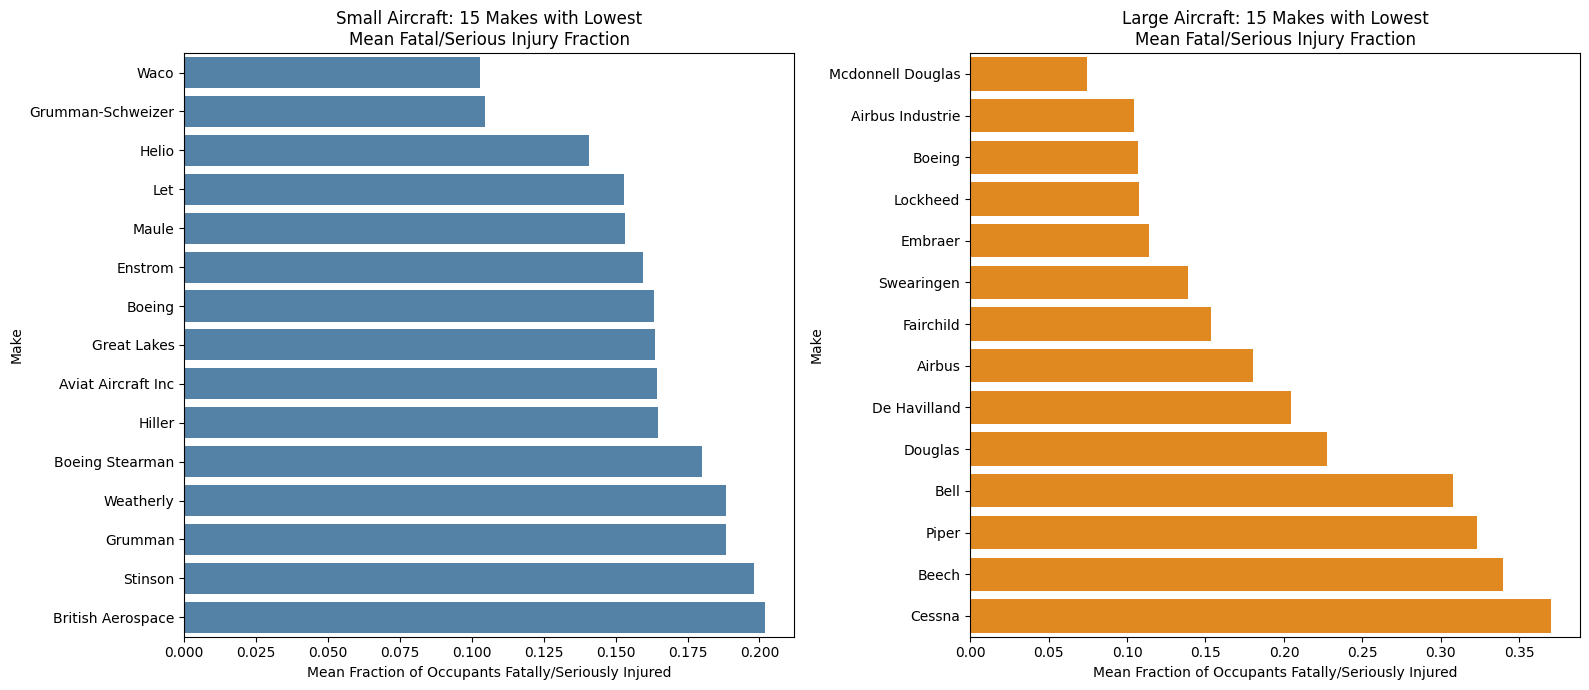

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

sns.barplot(x=top_small_makes['mean_frac'], y=top_small_makes.index, ax=axes[0], color='steelblue')
axes[0].set_title('Small Aircraft: 15 Makes with Lowest\nMean Fatal/Serious Injury Fraction')
axes[0].set_xlabel('Mean Fraction of Occupants Fatally/Seriously Injured')
axes[0].set_ylabel('Make')

sns.barplot(x=top_large_makes['mean_frac'], y=top_large_makes.index, ax=axes[1], color='darkorange')
axes[1].set_title('Large Aircraft: 15 Makes with Lowest\nMean Fatal/Serious Injury Fraction')
axes[1].set_xlabel('Mean Fraction of Occupants Fatally/Seriously Injured')
axes[1].set_ylabel('Make')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

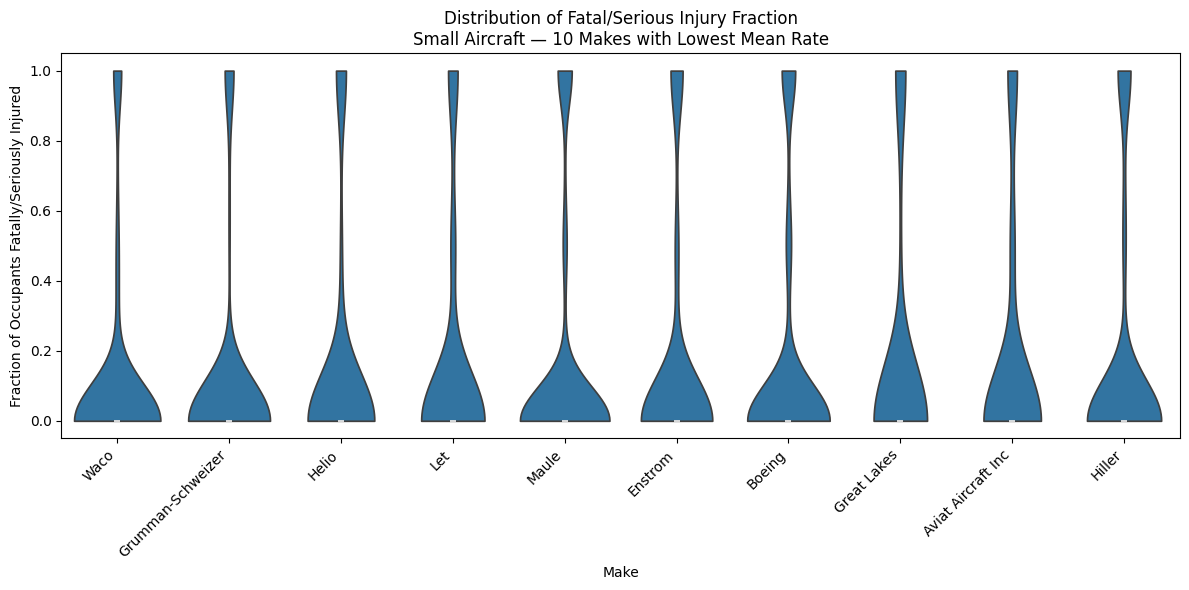

In [7]:
top10_small_makes = top_small_makes.head(10).index.tolist()
sub_small = df[(df['Size.Class'] == 'Small') & (df['Make'].isin(top10_small_makes))]

plt.figure(figsize=(12, 6))
sns.violinplot(data=sub_small, x='Make', y='Serious.Fatal.Fraction', order=top10_small_makes, cut=0)
plt.title('Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft — 10 Makes with Lowest Mean Rate')
plt.xlabel('Make')
plt.ylabel('Fraction of Occupants Fatally/Seriously Injured')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

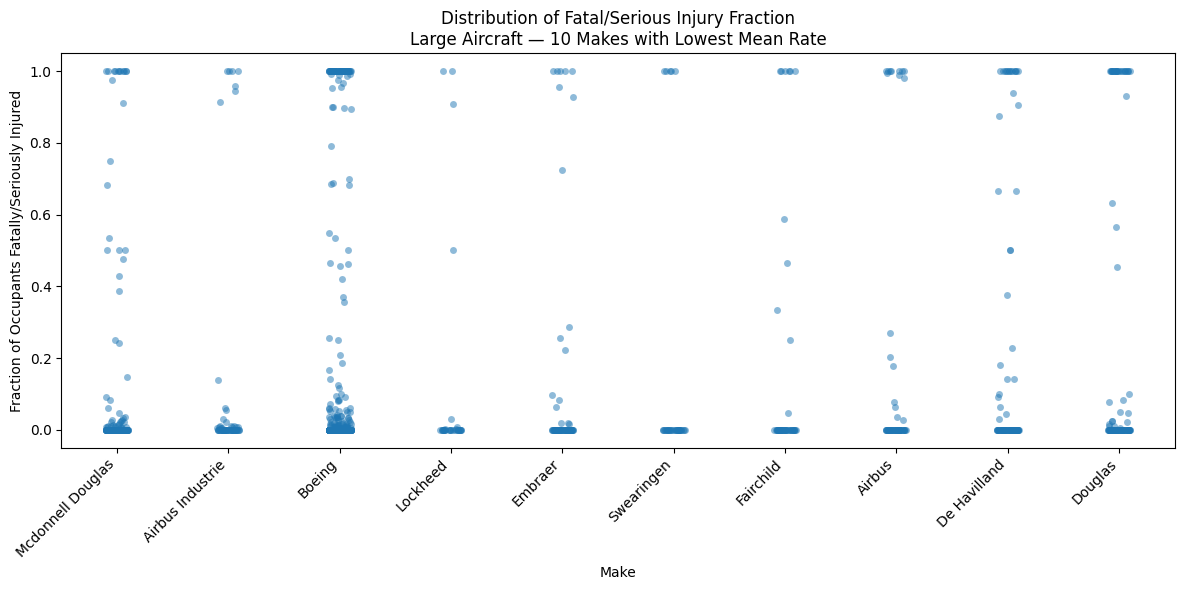

In [8]:
top10_large_makes = top_large_makes.head(10).index.tolist()
sub_large = df[(df['Size.Class'] == 'Large') & (df['Make'].isin(top10_large_makes))]

plt.figure(figsize=(12, 6))
sns.stripplot(data=sub_large, x='Make', y='Serious.Fatal.Fraction', order=top10_large_makes, jitter=True, alpha=0.5)
plt.title('Distribution of Fatal/Serious Injury Fraction\nLarge Aircraft — 10 Makes with Lowest Mean Rate')
plt.xlabel('Make')
plt.ylabel('Fraction of Occupants Fatally/Seriously Injured')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [9]:
def destroyed_rate_by_make(size_class, min_n=MIN_N_MAKE):
    sub = df[df['Size.Class'] == size_class]
    grp = sub.groupby('Make').agg(
        destroyed_rate=('Destroyed', 'mean'),
        n=('Destroyed', 'size')
    )
    grp = grp[grp['n'] >= min_n]
    grp['Size.Class'] = size_class
    return grp

destroyed_small = destroyed_rate_by_make('Small').sort_values('destroyed_rate').head(15)
destroyed_large = destroyed_rate_by_make('Large').sort_values('destroyed_rate').head(15)

print('Small aircraft — lowest destruction rates by Make')
display(destroyed_small)
print()
print('Large aircraft — lowest destruction rates by Make')
display(destroyed_large)

Small aircraft — lowest destruction rates by Make


,destroyed_rate,n,Size.Class
Make,,,
Grumman Acft Eng Cor-Schweizer,0.017241,58,Small
American Champion Aircraft,0.037736,53,Small
Aviat Aircraft Inc,0.039474,76,Small
Dehavilland,0.042553,94,Small
Diamond Aircraft Ind Inc,0.054054,74,Small
Flight Design Gmbh,0.060000,50,Small
Aviat,0.085714,140,Small
Waco,0.086957,138,Small
Balloon Works,0.090909,77,Small



Large aircraft — lowest destruction rates by Make


,destroyed_rate,n,Size.Class
Make,,,
Embraer,0.105263,76,Large
Mcdonnell Douglas,0.110236,254,Large
Boeing,0.113318,856,Large
Airbus Industrie,0.130435,69,Large
Swearingen,0.138889,36,Large
Lockheed,0.156250,32,Large
Airbus,0.183333,60,Large
Fairchild,0.200000,50,Large
De Havilland,0.221053,95,Large


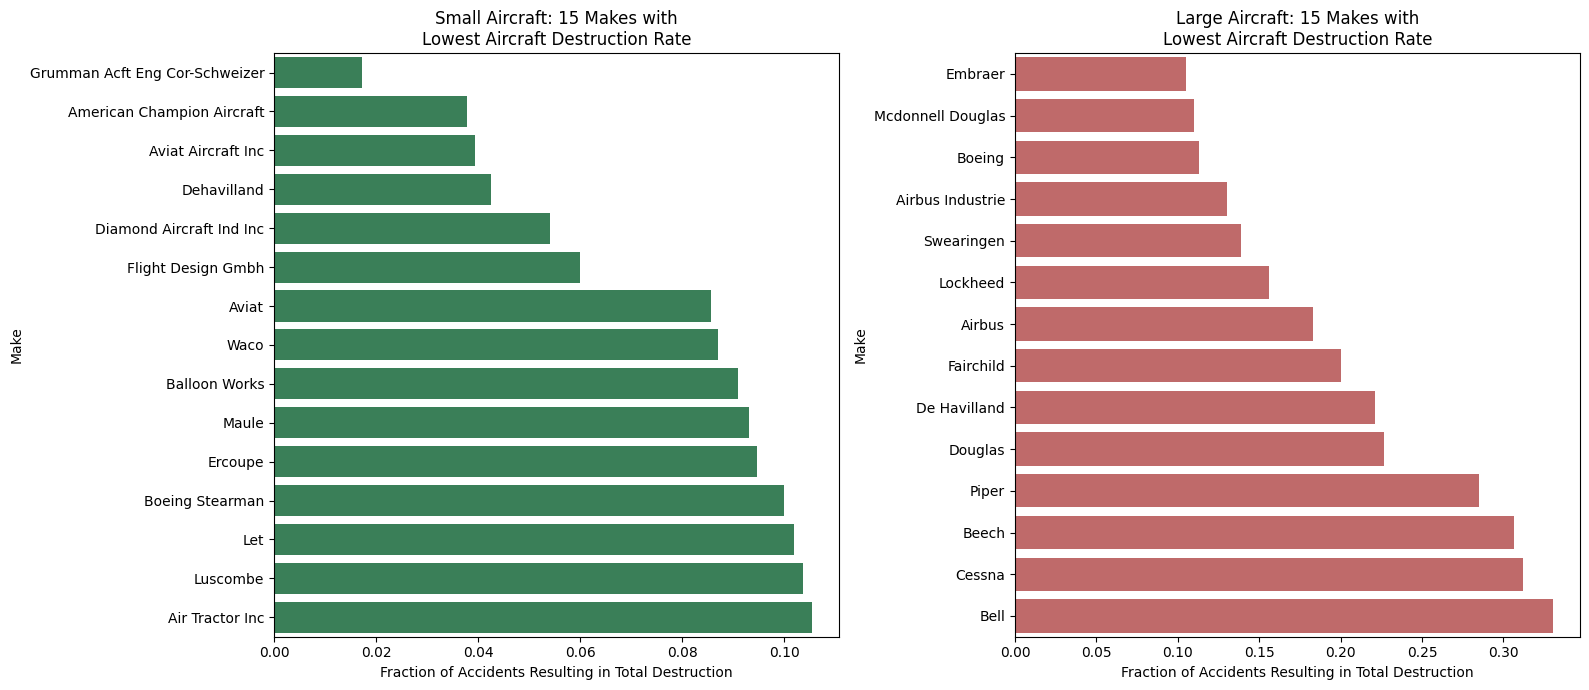

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=destroyed_small['destroyed_rate'], y=destroyed_small.index, ax=axes[0], color='seagreen')
axes[0].set_title('Small Aircraft: 15 Makes with\nLowest Aircraft Destruction Rate')
axes[0].set_xlabel('Fraction of Accidents Resulting in Total Destruction')

sns.barplot(x=destroyed_large['destroyed_rate'], y=destroyed_large.index, ax=axes[1], color='indianred')
axes[1].set_title('Large Aircraft: 15 Makes with\nLowest Aircraft Destruction Rate')
axes[1].set_xlabel('Fraction of Accidents Resulting in Total Destruction')

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### Discussion: Findings by Make

**Small aircraft.** Makes such as Waco, Grumman-Schweizer, Helio, Let, and Maule show the lowest mean fraction of occupants fatally or seriously injured (roughly 10-16%) among small aircraft with at least 30 recorded accidents. The violin plots show that most of these makes have a heavy concentration of accidents at or near a 0% injury fraction, with a long tail toward more severe outcomes — meaning that for these makes, the *typical* accident is survivable with no serious injury, even though a minority of accidents remain severe. When we instead rank by destruction rate, a somewhat different (though overlapping) set of makes comes out on top, which tells us that "surviving with minor injuries" and "aircraft not being written off" are related but distinct outcomes — a plane can be totaled while everyone walks away, or vice versa.

**Large aircraft.** Among large aircraft with sufficient sample size, McDonnell Douglas, Airbus Industrie, and Boeing show the lowest mean injury fractions (7-16%), notably lower than the worst performers in this group (Cessna, Beech, and Piper — which, in the "large" bucket, likely represent bigger multi-engine variants of these makes rather than their typical small-aircraft lineups). This is a meaningful finding for the client: it suggests that within large aircraft, the manufacturer/model family matters — jet-oriented builders (Boeing, McDonnell Douglas, Airbus) systematically outperform general-aviation makes that happen to have a few larger models.

**Caveat:** these injury/destruction fractions describe accidents that were serious enough to be reported to the NTSB — they say nothing about the underlying accident *rate* per flight hour or per aircraft in service, which we don't have data on. A make with a low injury fraction here could still be more prone to accidents overall; what we can say is that *when* an accident happens, some makes see less severe outcomes than others.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

We now drill down from Make to specific plane type (`Make.Model`). As with Makes, we require a reasonable sample size per model — here we use a lower threshold of **10 records**, since individual models naturally have fewer accidents than their parent Make.

In [11]:
MIN_N_MODEL = 10

large_model_grp = (df[df['Size.Class'] == 'Large']
                    .groupby('Make.Model')
                    .agg(mean_frac=('Serious.Fatal.Fraction', 'mean'), n=('Serious.Fatal.Fraction', 'size')))
large_model_grp = large_model_grp[large_model_grp['n'] >= MIN_N_MODEL]

top_large_models = large_model_grp.sort_values('mean_frac').head(15)
top_large_models

,mean_frac,n
Make.Model,,
Boeing 777,0.000000,24
Boeing 757-222,0.000000,10
Boeing 757-232,0.000000,10
Mcdonnell Douglas MD-11F,0.000000,10
Mcdonnell Douglas MD-80,0.000978,11
Mcdonnell Douglas MD-88,0.003247,17
Mcdonnell Douglas DC-9-51,0.005693,11
Mcdonnell Douglas DC-10-10,0.028679,19
Boeing 727-200,0.043742,24


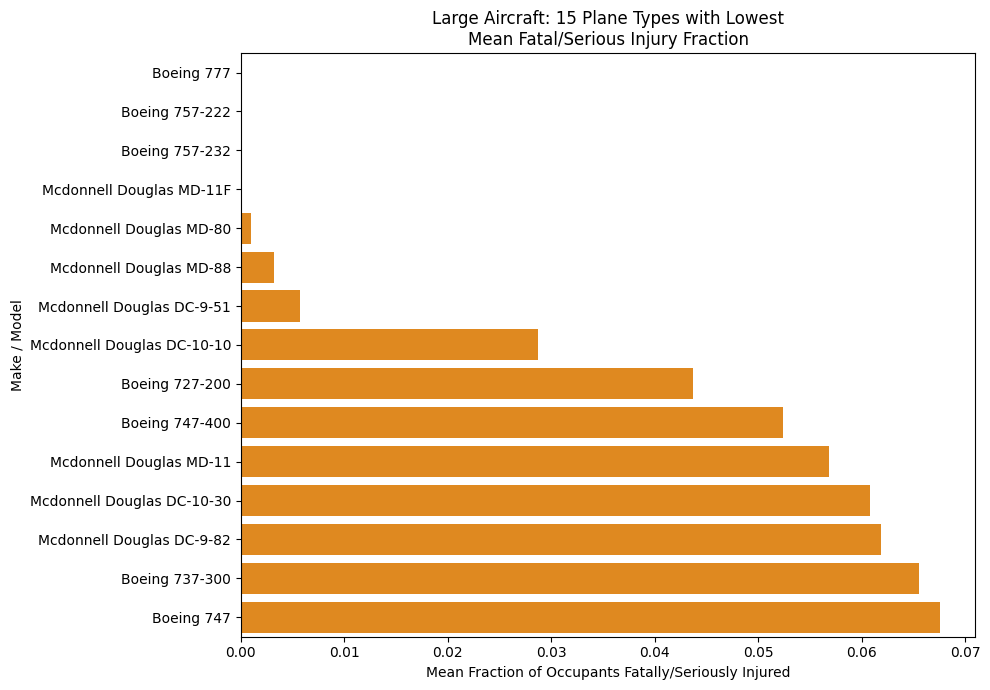

In [12]:
plt.figure(figsize=(10, 7))
sns.barplot(x=top_large_models['mean_frac'], y=top_large_models.index, color='darkorange')
plt.title('Large Aircraft: 15 Plane Types with Lowest\nMean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fraction of Occupants Fatally/Seriously Injured')
plt.ylabel('Make / Model')
plt.tight_layout()
plt.show()

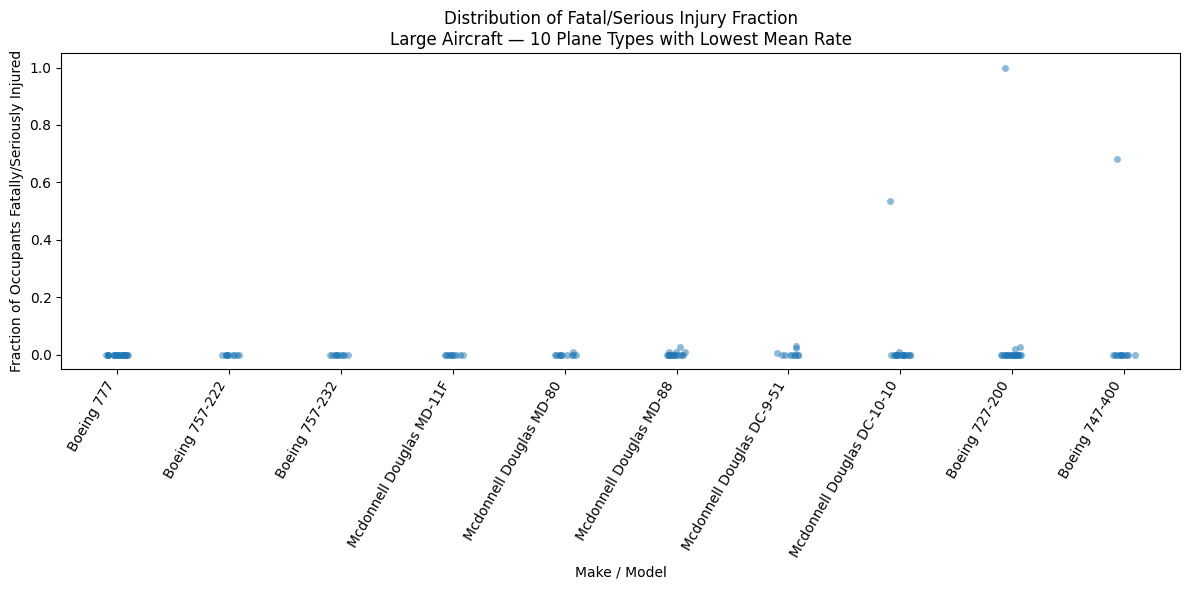

In [13]:
top10_large_model_names = top_large_models.head(10).index.tolist()
sub_large_models = df[df['Make.Model'].isin(top10_large_model_names)]

plt.figure(figsize=(12, 6))
sns.stripplot(data=sub_large_models, x='Make.Model', y='Serious.Fatal.Fraction', order=top10_large_model_names,
              jitter=True, alpha=0.5)
plt.title('Distribution of Fatal/Serious Injury Fraction\nLarge Aircraft — 10 Plane Types with Lowest Mean Rate')
plt.xlabel('Make / Model')
plt.ylabel('Fraction of Occupants Fatally/Seriously Injured')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [14]:
small_model_sub = df[(df['Size.Class'] == 'Small') & (df['Make'].isin(top10_small_makes))]

small_model_grp = (small_model_sub
                    .groupby('Make.Model')
                    .agg(mean_frac=('Serious.Fatal.Fraction', 'mean'), n=('Serious.Fatal.Fraction', 'size')))
small_model_grp = small_model_grp[small_model_grp['n'] >= MIN_N_MODEL]

top_small_models = small_model_grp.sort_values('mean_frac').head(15)
top_small_models

,mean_frac,n
Make.Model,,
Maule MX-7-235,0.029412,17
Grumman-Schweizer G-164A,0.034014,49
Hiller UH12E,0.045455,11
Hiller 12E,0.050000,10
Maule M-7-235B,0.050000,10
Maule M-4,0.055556,18
Enstrom F-28A,0.069444,36
Boeing E75,0.075758,33
Hiller UH-12C,0.083333,18


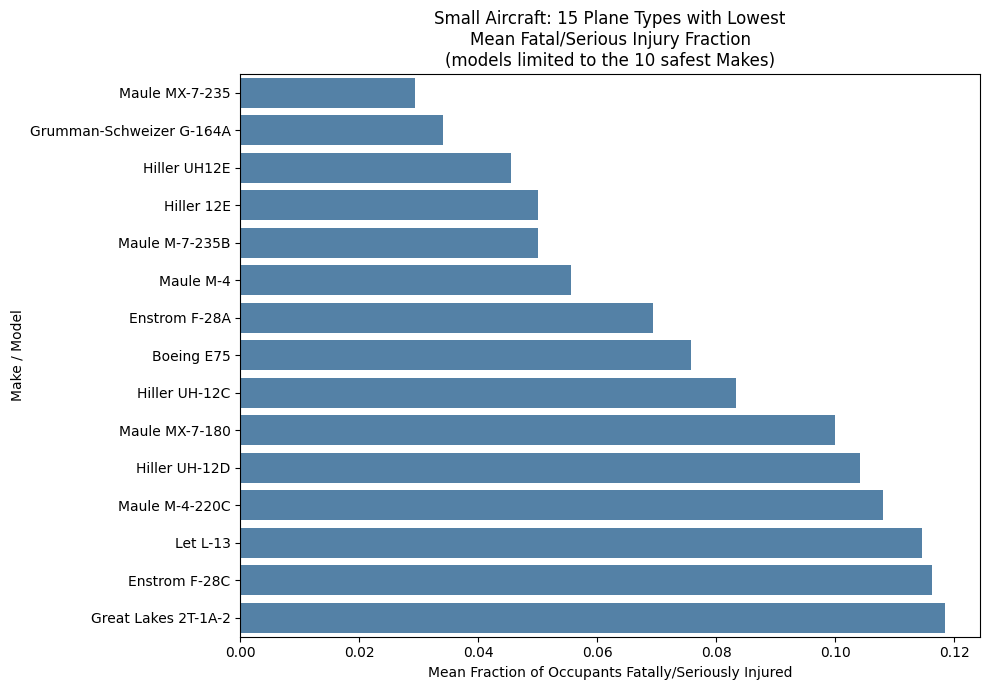

In [15]:
plt.figure(figsize=(10, 7))
sns.barplot(x=top_small_models['mean_frac'], y=top_small_models.index, color='steelblue')
plt.title('Small Aircraft: 15 Plane Types with Lowest\nMean Fatal/Serious Injury Fraction\n(models limited to the 10 safest Makes)')
plt.xlabel('Mean Fraction of Occupants Fatally/Seriously Injured')
plt.ylabel('Make / Model')
plt.tight_layout()
plt.show()

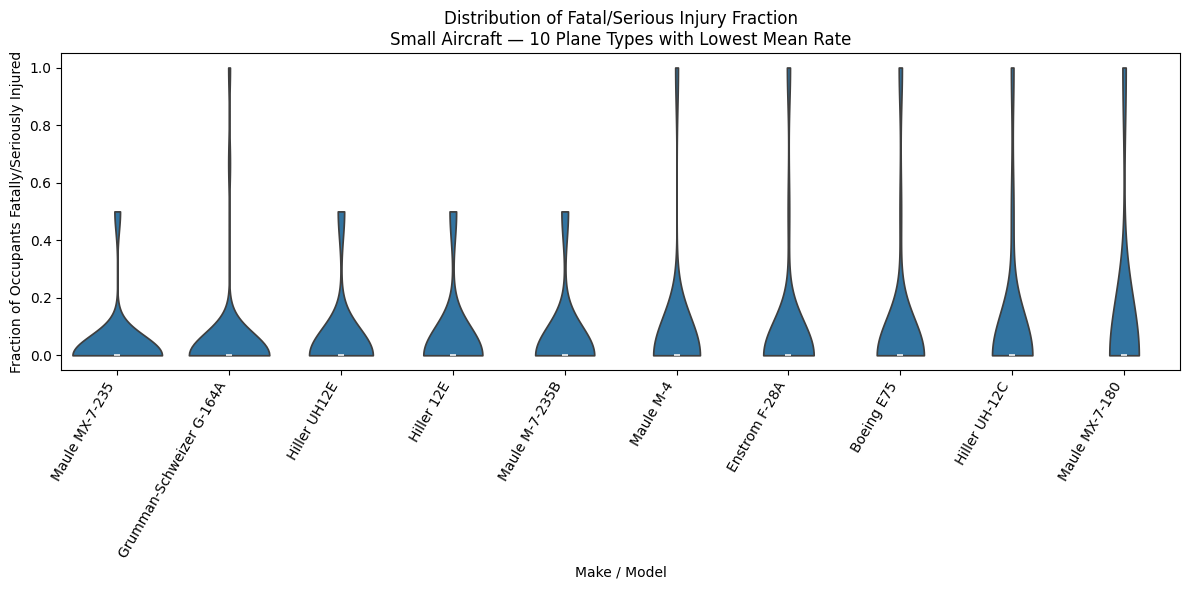

In [16]:
top10_small_model_names = top_small_models.head(10).index.tolist()
sub_small_models = df[df['Make.Model'].isin(top10_small_model_names)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=sub_small_models, x='Make.Model', y='Serious.Fatal.Fraction', order=top10_small_model_names, cut=0)
plt.title('Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft — 10 Plane Types with Lowest Mean Rate')
plt.xlabel('Make / Model')
plt.ylabel('Fraction of Occupants Fatally/Seriously Injured')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#### Discussion: Findings by Specific Airplane Type

**Large aircraft.** At the model level, the safest large plane types include the Boeing 777, several Boeing 757 variants, and the McDonnell Douglas MD-11F, all showing a mean fatal/serious injury fraction at or near 0% across at least 10 recorded accidents. More broadly, McDonnell Douglas and Boeing widebody/narrowbody jets dominate the top of this list — reinforcing the Make-level finding that modern commercial jet designs tend to produce more survivable accidents than older or smaller multi-engine aircraft. The strip plot shows these models cluster tightly near 0, with only occasional accidents showing meaningfully higher injury fractions — a pattern consistent with a "typically survivable, occasionally catastrophic" profile rather than moderate injury being the norm.

**Small aircraft.** Among the safest small makes, specific models like the Maule MX-7-235, Grumman-Schweizer G-164A (an agricultural aircraft), and various Hiller helicopters/Maule variants show the lowest injury fractions. The violin plots reveal these small-aircraft models have wider distributions than the large jets above — more spread between "no injury" and "serious injury" outcomes — which makes sense given small aircraft accidents are more likely to be lower-speed, single-occupant events where outcome depends heavily on circumstances (e.g., a field landing vs. a stall/spin).

**Recommendation for the client:** for large aircraft, we'd recommend favoring modern Boeing (777, 757, 747-400) and McDonnell Douglas (MD-11, MD-80/88, DC-10) models. For small aircraft, Maule, Grumman-Schweizer, Hiller, and Enstrom models stand out as having the most favorable injury outcomes among makes with a meaningful accident history.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Factor 1: Weather Condition

We compare accidents that occurred in **VMC** (Visual Meteorological Conditions — clear enough to fly by sight) vs. **IMC** (Instrument Meteorological Conditions — poor visibility, requiring instrument flying).

In [17]:
weather_summary = df.groupby('Weather.Condition').agg(
    mean_injury_frac=('Serious.Fatal.Fraction', 'mean'),
    destroyed_rate=('Destroyed', 'mean'),
    n=('Destroyed', 'size')
)
weather_summary

,mean_injury_frac,destroyed_rate,n
Weather.Condition,,,
IMC,0.662541,0.586935,4975
Unknown,0.550131,0.403391,2536
VMC,0.223548,0.174193,56690


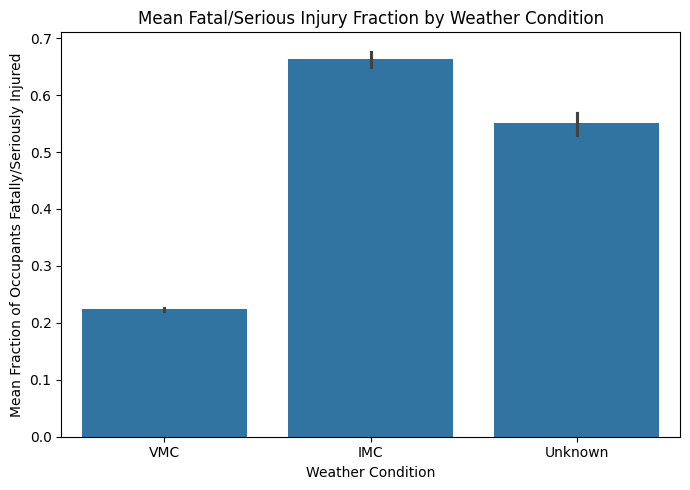

In [18]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Weather.Condition', y='Serious.Fatal.Fraction', order=['VMC', 'IMC', 'Unknown'],
            errorbar=('ci', 95))
plt.title('Mean Fatal/Serious Injury Fraction by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Mean Fraction of Occupants Fatally/Seriously Injured')
plt.tight_layout()
plt.show()

In [19]:
from scipy import stats

vmc_frac = df[df['Weather.Condition'] == 'VMC']['Serious.Fatal.Fraction']
imc_frac = df[df['Weather.Condition'] == 'IMC']['Serious.Fatal.Fraction']

t_stat, p_val = stats.ttest_ind(vmc_frac, imc_frac, equal_var=False)
print(f'VMC mean: {vmc_frac.mean():.3f} (n={len(vmc_frac)})')
print(f'IMC mean: {imc_frac.mean():.3f} (n={len(imc_frac)})')
print(f't-statistic: {t_stat:.2f}, p-value: {p_val:.2e}')

VMC mean: 0.224 (n=56690)
IMC mean: 0.663 (n=4975)
t-statistic: -65.42, p-value: 0.00e+00


**Discussion.** Weather condition has a large and statistically significant effect on accident severity. Accidents in IMC have a mean fatal/serious injury fraction of roughly **66%**, versus about **22%** in VMC — nearly a 3x difference — and this gap is highly statistically significant (Welch's t-test, p ≈ 0). Aircraft destruction rates follow the same pattern (59% in IMC vs. 17% in VMC). This makes intuitive sense: flying in poor visibility without adequate instrument proficiency or equipment is a well-documented risk factor, and accidents that occur in IMC are more likely to involve loss of control or controlled flight into terrain, which tend to be more severe than the mechanical or landing-related mishaps that dominate VMC accidents. For the client, this suggests that an aircraft/pilot combination with strong instrument flight capability (and a pilot with an instrument rating and current experience) is a meaningfully safer profile, independent of the aircraft make/model itself.

### Factor 2: Broad Phase of Flight

In [20]:
phase_summary = df.groupby('Broad.phase.of.flight').agg(
    mean_injury_frac=('Serious.Fatal.Fraction', 'mean'),
    destroyed_rate=('Destroyed', 'mean'),
    n=('Destroyed', 'size')
).sort_values('mean_injury_frac')
phase_summary

,mean_injury_frac,destroyed_rate,n
Broad.phase.of.flight,,,
Taxi,0.017978,0.026820,1566
Landing,0.038062,0.045125,12698
Standing,0.092346,0.132701,633
Takeoff,0.226493,0.220002,9609
Go-around,0.299583,0.290323,1178
Descent,0.331110,0.316916,1401
Approach,0.342890,0.291328,5039
Unknown,0.349532,0.166810,16318
Cruise,0.351218,0.341736,8053


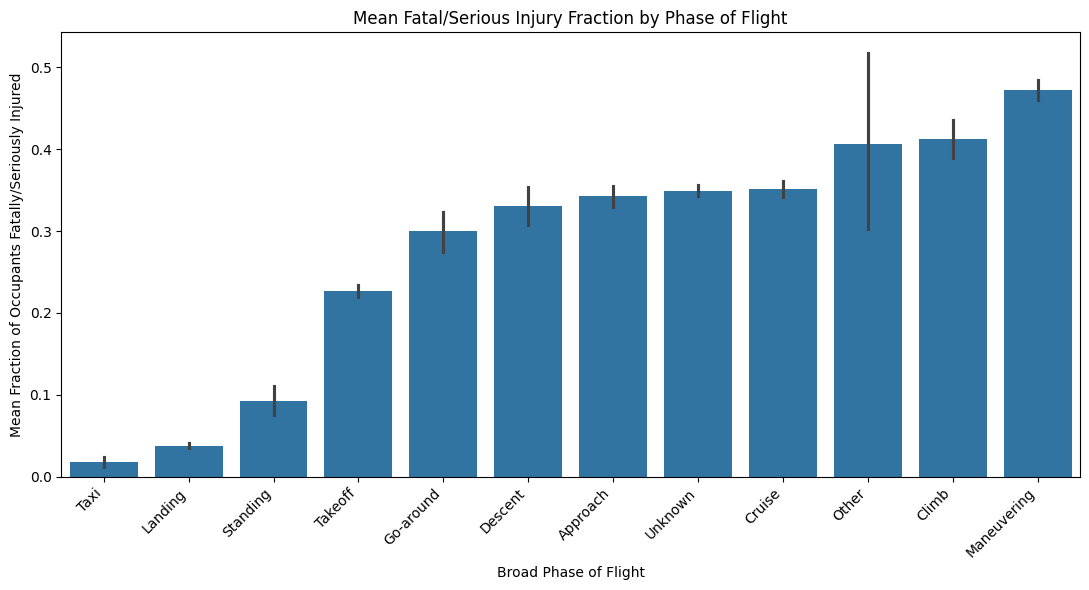

In [21]:
phase_order = phase_summary.index.tolist()

plt.figure(figsize=(11, 6))
sns.barplot(data=df, x='Broad.phase.of.flight', y='Serious.Fatal.Fraction', order=phase_order,
            errorbar=('ci', 95))
plt.title('Mean Fatal/Serious Injury Fraction by Phase of Flight')
plt.xlabel('Broad Phase of Flight')
plt.ylabel('Mean Fraction of Occupants Fatally/Seriously Injured')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Discussion.** Phase of flight also shows a clear and intuitive pattern. The safest phases are **Taxi** (~2% injury fraction) and **Landing** (~4%) — accidents here tend to happen at low speed on the ground/near the ground, giving occupants a much better chance of walking away. The most dangerous phases are **Maneuvering** (~47%), **Climb** (~41%), and **Cruise** (~35%) — these tend to involve higher altitude/speed, less margin for recovery, and (for maneuvering in particular) intentional low-altitude flying such as aerial application or sightseeing, which carries inherently less room for error. **Go-around** and **Approach** also show elevated risk (~30-34%), consistent with these being high-workload phases where a rushed or mishandled maneuver can escalate quickly.

For the client, this suggests that accident severity isn't just a property of the aircraft — operational context matters a great deal. Two otherwise-identical aircraft could have very different expected outcomes depending on what phase of flight an accident is more likely to occur in for their typical use case (e.g., agricultural aircraft that spend more time maneuvering at low altitude vs. airliners that spend more time in stable cruise).